# PD LEDD Change — Conformal Prediction Comparison

Compares five conformal prediction methods on real PD data across α ∈ {0.80, 0.85, 0.90, 0.95}.

| Method | Label | Description |
|--------|-------|-------------|
| `adapted_original_pipeline` | **CPCI** | Proposed two-stage method|
| `adapted_vanilla_model` | **VCI** | Vanilla conformal baseline |
| `adapted_RF_XGB_model` | **CPCI-XGB** | CPCI with RF classifier + XGBoost regressor |
| `adapted_ad_hoc_model` | **WEIGHTED-VCI** | Unified weighted nonconformity score |
| `adapted_class_conditional_model` | **CLASS-COND** | Separate calibration per class |


## 1 · Imports

In [1]:
# ==============================================================================
# OLD CODE
# ==============================================================================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import xgboost as xgb
# import warnings
# warnings.filterwarnings('ignore')
#
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing   import MinMaxScaler
# from sklearn.ensemble        import RandomForestClassifier
# from sklearn.metrics         import roc_auc_score
# # from venn_abers              import VennAbers
#
# RANDOM_STATE   = 42
# LARGE_CONSTANT = 100_000_000
# ALPHA_VALUES   = [0.7, 0.8, 0.9, 0.95]

# ==============================================================================
# UPDATED CODE
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
RANDOM_STATES = np.arange(100)
LARGE_CONSTANT = 100_000_000
ALPHA_VALUES = [0.7, 0.8, 0.9, 0.95]

# Important:
# Set this to True only if the real outcome is naturally nonnegative.
# For LEDD percentage/change outcomes, negative values may be meaningful, so the safer default is False.
TRUNCATE_NONNEGATIVE = False


## 2 · Load and preprocess data

In [2]:
# ==============================================================================
# OLD CODE
# ==============================================================================
# data = pd.read_csv('data/data_kth2.csv')
# normalized_pctg_change = np.loadtxt('data/series_kth2.txt')
# # Regression target — save before dropping
# # normalized_pctg_change = data['normalized_percent_change']
# # data.drop(columns=['normalized_percent_change'], inplace=True)
#
# # One-hot encode demographics
# demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
# xgboost_df = pd.get_dummies(data, columns=demographic_vars)
#
# # MinMaxScale numeric features
# scaler = MinMaxScaler()
# numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay',
#                 'days_since_last_visit', 'days_to_diagnosis']
# for var in numeric_vars:
#     if var in xgboost_df.columns:
#         xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])
#
# # Keep 'prediction' last
# pred_col = xgboost_df.pop('prediction')
# xgboost_df['prediction'] = pred_col
#
# X        = xgboost_df.iloc[:, :-1].values
# y_binary = xgboost_df.iloc[:,  -1].values
# y_cont   = normalized_pctg_change
#
# print(f"X shape      : {X.shape}")
# print(f"y_binary     : {np.bincount(y_binary.astype(int))} (0=no-change, 1=change)")
# print(f"y_cont range : [{y_cont.min():.3f}, {y_cont.max():.3f}]")
# print(f"Zero fraction: {(y_cont == 0).mean():.1%}")

# ==============================================================================
# UPDATED CODE
# ==============================================================================
data = pd.read_csv('data/data_kth2.csv')
normalized_pctg_change = np.loadtxt('data/series_kth2.txt')


# One-hot encode demographics
demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
xgboost_df = pd.get_dummies(data, columns=demographic_vars)

# MinMaxScale numeric features
scaler = MinMaxScaler()
numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay',
                'days_since_last_visit', 'days_to_diagnosis']
for var in numeric_vars:
    if var in xgboost_df.columns:
        xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])

# Keep 'prediction' last
pred_col = xgboost_df.pop('prediction')
xgboost_df['prediction'] = pred_col

# Use numeric float matrix so LinearRegression/SVM/Logistic/XGBoost all receive the same design.
X        = xgboost_df.iloc[:, :-1].astype(float).values
y_binary = xgboost_df.iloc[:,  -1].astype(int).values
y_cont   = normalized_pctg_change.astype(float)

print(f"X shape      : {X.shape}")
print(f"y_binary     : {np.bincount(y_binary.astype(int))} (0=no-change, 1=change)")
print(f"y_cont range : [{y_cont.min():.3f}, {y_cont.max():.3f}]")
print(f"Zero fraction: {(y_cont == 0).mean():.1%}")

if TRUNCATE_NONNEGATIVE and np.nanmin(y_cont) < 0:
    print("Warning: TRUNCATE_NONNEGATIVE=True but y_cont contains negative values.")


X shape      : (362, 39)
y_binary     : [162 200] (0=no-change, 1=change)
y_cont range : [-1.000, 1.000]
Zero fraction: 44.8%


## 3 · Model parameters

In [3]:
binary_params = {
    'max_depth': 7,
    'learning_rate': 0.01,
    'n_estimators': 800,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'verbosity': 0,
    'random_state': RANDOM_STATE
}

regression_params_short = {
    'max_depth': 7,
    'learning_rate': 0.1,
    'n_estimators': 700,
    'objective': 'reg:squarederror',
    'verbosity': 0,
    'random_state': RANDOM_STATE
}


## 4 · Data splitting helper

In [4]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# def split_into_five_equal_parts(X, y_binary, y_continuous, random_state=42):
#     """
#     Splits data into 5 equal parts (20% each):
#     train | calib1 | calib2 | calib3 | test
#     """
#     X_temp, X_test, yb_temp, yb_test, yc_temp, yc_test = train_test_split(
#         X, y_binary, y_continuous, test_size=0.2, random_state=random_state)
#
#     X_train, X_temp2, yb_train, yb_temp2, yc_train, yc_temp2 = train_test_split(
#         X_temp, yb_temp, yc_temp, test_size=0.75, random_state=random_state)
#
#     X_c1, X_temp3, yb_c1, yb_temp3, yc_c1, yc_temp3 = train_test_split(
#         X_temp2, yb_temp2, yc_temp2, test_size=0.5, random_state=random_state)
#
#     X_c2, X_c3, yb_c2, yb_c3, yc_c2, yc_c3 = train_test_split(
#         X_temp3, yb_temp3, yc_temp3, test_size=0.5, random_state=random_state)
#
#     return (X_train, X_c1, X_c2, X_c3, X_test,
#             yb_train, yb_c1, yb_c2, yb_c3, yb_test,
#             yc_train, yc_c1, yc_c2, yc_c3, yc_test)

# ==============================================================================
# UPDATED CODE
# ==============================================================================

def split_into_five_equal_parts(X, y_binary, y_continuous, random_state=42):
    """
    Email update:
    split data into five balanced parts:
    train | calib1 | calib2 | calib3 | test = 20% each.
    """
    X_temp, X_test, yb_temp, yb_test, yc_temp, yc_test = train_test_split(
        X, y_binary, y_continuous, test_size=0.2, random_state=random_state
    )

    # From the remaining 80%, take 25% as training = 20% of full data.
    X_train, X_temp2, yb_train, yb_temp2, yc_train, yc_temp2 = train_test_split(
        X_temp, yb_temp, yc_temp, test_size=0.75, random_state=random_state
    )

    # From the remaining 60%, take 1/3 as calib1 = 20% of full data.
    X_c1, X_temp3, yb_c1, yb_temp3, yc_c1, yc_temp3 = train_test_split(
        X_temp2, yb_temp2, yc_temp2, test_size=2/3, random_state=random_state
    )

    # Split the remaining 40% into calib2 and calib3 = 20% each.
    X_c2, X_c3, yb_c2, yb_c3, yc_c2, yc_c3 = train_test_split(
        X_temp3, yb_temp3, yc_temp3, test_size=0.5, random_state=random_state
    )

    return (X_train, X_c1, X_c2, X_c3, X_test,
            yb_train, yb_c1, yb_c2, yb_c3, yb_test,
            yc_train, yc_c1, yc_c2, yc_c3, yc_test)


def get_xgb_classifier(random_state):
    params = binary_params.copy()
    params['random_state'] = random_state
    return xgb.XGBClassifier(**params)


def get_xgb_regressor(random_state):
    params = regression_params_short.copy()
    params['random_state'] = random_state
    return xgb.XGBRegressor(**params)


def make_logistic_classifier(random_state):
    """
    CPCI / CLASS-COND / WEIGHTED-VCI classifier:
    logistic regression on second-order polynomial features.
    """
    return Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('logistic', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            max_iter=10000,
            l1_ratio=0.5,
            random_state=random_state
        ))
    ])


def make_svm_classifier(random_state):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', probability=True, random_state=random_state))
    ])


def make_svm_regressor():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf'))
    ])


def fit_classifier_safely(clf, X_train, y_train):
    """
    Robust helper for repeated real-data splits.
    If a random split has only one class in the training set, use a DummyClassifier instead of crashing the full 100-split run.
    """
    y_train = np.asarray(y_train).astype(int)
    unique = np.unique(y_train)
    if len(unique) < 2:
        dummy = DummyClassifier(strategy='constant', constant=int(unique[0]))
        dummy.fit(X_train, y_train)
        return dummy

    clf.fit(X_train, y_train)
    return clf


def predict_nonzero_proba(clf, X):
    """
    Return P(Y != 0 | X), i.e., probability of binary class 1.
    Handles classifiers whose classes_ may not be ordered or may contain one class.
    """
    proba = clf.predict_proba(X)
    classes = np.asarray(clf.classes_).astype(int)

    if 1 in classes:
        idx = int(np.where(classes == 1)[0][0])
        return proba[:, idx]

    return np.zeros(X.shape[0])


def fit_regressor_safely(reg, X_train, yb_train, yc_train, nonzero_only=False):
    """
    Fit on nonzero outcomes when requested.
    If a split contains no nonzero training outcomes, fall back to all training data.
    """
    if nonzero_only:
        mask = np.asarray(yb_train) == 1
        if np.sum(mask) == 0:
            mask = np.ones(len(yb_train), dtype=bool)
    else:
        mask = np.ones(len(yb_train), dtype=bool)

    reg.fit(X_train[mask], yc_train[mask])
    return reg


def conformal_quantile(values, q, large_constant=LARGE_CONSTANT):
    values = np.asarray(values, dtype=float)
    if len(values) == 0 or np.isnan(q):
        return np.nan
    q = float(np.clip(q, 0, 1))
    return np.quantile(np.append(values, large_constant), q)


def truncate_pi_at_zero_unless_fully_negative(lb, ub, truncate=TRUNCATE_NONNEGATIVE):
    """
    Optional nonnegative-outcome truncation.

    If the outcome is naturally nonnegative, intersect the interval with [0, infinity).
    If the interval is fully negative, leave it unchanged.
    If the outcome can naturally be negative, set TRUNCATE_NONNEGATIVE=False.
    """
    lb = np.asarray(lb, dtype=float).copy()
    ub = np.asarray(ub, dtype=float).copy()

    if not truncate:
        return lb, ub

    mask_not_fully_negative = ub >= 0
    lb[mask_not_fully_negative] = np.maximum(lb[mask_not_fully_negative], 0)
    return lb, ub


def compute_interval_metrics(lb, ub, yc_test, yb_test,
                             pred_nonzero_mask=None,
                             covered_override=None,
                             contains_zero_override=None,
                             extra=None):
    """
    Metrics:
      coverage                  = average overall coverage
      avg_width                 = average overall interval length
      inclusion_zero            = proportion of prediction sets containing 0
      avg_width_pred_nonzero    = average length among patients predicted nonzero
      coverage_nonzero          = coverage among true nonzero outcomes
      avg_width_nonzero         = length among true nonzero outcomes
    """
    lb = np.asarray(lb, dtype=float)
    ub = np.asarray(ub, dtype=float)
    yc_test = np.asarray(yc_test, dtype=float)
    yb_test = np.asarray(yb_test).astype(int)

    if covered_override is None:
        covered = (yc_test >= lb) & (yc_test <= ub)
    else:
        covered = np.asarray(covered_override, dtype=bool)

    if contains_zero_override is None:
        contains_zero = (lb <= 0) & (ub >= 0)
    else:
        contains_zero = np.asarray(contains_zero_override, dtype=bool)

    if pred_nonzero_mask is None:
        pred_nonzero_mask = np.ones(len(yc_test), dtype=bool)
    else:
        pred_nonzero_mask = np.asarray(pred_nonzero_mask, dtype=bool)

    true_nonzero = yb_test == 1
    lengths = ub - lb

    metrics = {
        'coverage': np.mean(covered),
        'coverage_nonzero': np.mean(covered[true_nonzero]) if np.any(true_nonzero) else np.nan,
        'avg_width': np.mean(lengths),
        'avg_width_nonzero': np.mean(lengths[true_nonzero]) if np.any(true_nonzero) else np.nan,
        'avg_width_pred_nonzero': np.mean(lengths[pred_nonzero_mask]) if np.any(pred_nonzero_mask) else 0.0,
        'inclusion_zero': np.mean(contains_zero)
    }

    if extra is not None:
        metrics.update(extra)

    return metrics


## 5 · Method 1 — CPCI (Logistic classifier + Linear regression)

In [5]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# def adapted_original_pipeline(X, y_binary, y_continuous,
#                                alpha_tilda=0.9, choose_method="original",
#                                random_state=RANDOM_STATE):
#     """
#     Proposed CPCI method: XGBoost classifier + XGBoost regressor.
#     Three calibration sets. Tunes threshold r to minimise interval length.
#     """
#     np.random.seed(random_state)
#     (X_train, X_c1, X_c2, X_c3, X_test,
#      yb_train, yb_c1, yb_c2, yb_c3, yb_test,
#      yc_train, yc_c1, yc_c2, yc_c3, yc_test
#      ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)
#
#     classifier = xgb.XGBClassifier(**binary_params)
#     classifier.fit(X_train, yb_train)
#
#     nz = yb_train == 1
#     reg_nz = xgb.XGBRegressor(**regression_params_short)
#     reg_nz.fit(X_train[nz], yc_train[nz])
#
#     reg_all = xgb.XGBRegressor(**regression_params_short)
#     reg_all.fit(X_train, yc_train)
#
#     p1 = classifier.predict_proba(X_c1)[:, 1]
#     p2 = classifier.predict_proba(X_c2)[:, 1]
#     p3 = classifier.predict_proba(X_c3)[:, 1]
#
#     results = []
#     for r in np.arange(0.1, 0.95, 0.05):
#         alpha_r = np.quantile(np.append(p1, LARGE_CONSTANT), r)
#
#         zeros2 = p2 <= alpha_r
#         if not np.any(zeros2): continue
#
#         beta_hat = np.mean(yb_c2[zeros2] == 0)
#         n2       = len(X_c2)
#         beta_adj = beta_hat - 0.1 * np.sqrt(np.log(n2) / n2)
#         if np.isnan(beta_adj): continue
#
#         cur = {'r': r, 'alpha_r': alpha_r, 'fallback': False, 'length': np.inf}
#
#         if beta_adj < alpha_tilda:
#             resid          = np.abs(yc_c3 - reg_all.predict(X_c3))
#             cur['length']  = np.quantile(np.append(resid, LARGE_CONSTANT), alpha_tilda)
#             cur['fallback'] = True
#         else:
#             fq = (alpha_tilda + 1/len(X_c3) - beta_adj * r) / (1 - r)
#             if fq > 1: continue
#             fq = max(0, fq)
#             nz3 = p3 > alpha_r
#             if not np.any(nz3): continue
#             resid     = np.abs(yc_c3[nz3] - reg_nz.predict(X_c3[nz3]))
#             raw       = np.quantile(np.append(resid, LARGE_CONSTANT), fq)
#             cur['length'] = raw * (1 - r) if choose_method == "original" else raw
#
#         results.append(cur)
#
#     if not results:
#         raise ValueError("No valid r found.")
#
#     best = min(results, key=lambda x: x['length'])
#     lb = np.zeros(len(X_test))
#     ub = np.zeros(len(X_test))
#
#     if best['fallback']:
#         preds = reg_all.predict(X_test)
#         lb = preds - best['length']
#         ub = preds + best['length']
#     else:
#         pt    = classifier.predict_proba(X_test)[:, 1]
#         nz_t  = pt > best['alpha_r']
#         preds = reg_nz.predict(X_test)
#         m     = best['length'] / (1 - best['r']) if choose_method == "original" else best['length']
#         lb[nz_t] = preds[nz_t] - m
#         ub[nz_t] = preds[nz_t] + m
#
#     w   = (yc_test >= lb) & (yc_test <= ub)
#     nz  = yb_test == 1
#     lens = ub - lb
#     return lb, ub, yc_test, {
#         'coverage':          np.mean(w),
#         'coverage_nonzero':  np.mean(w[nz]) if np.any(nz) else np.nan,
#         'avg_width':         np.mean(lens),
#         'avg_width_nonzero': np.mean(lens[nz]) if np.any(nz) else np.nan,
#         'method_used':       'VCI' if best['fallback'] else 'CPCI',
#         'best_r':            best['r']
#     }

# ==============================================================================
# UPDATED CODE
# ==============================================================================

def adapted_original_pipeline(X, y_binary, y_continuous,
                               alpha_tilda=0.9, choose_method="original",
                               random_state=RANDOM_STATE):
    """
    CPCI:
      classifier = LogisticRegression
      nonzero outcome model = LinearRegression
      fallback vanilla model = LinearRegression
    """
    np.random.seed(random_state)

    (X_train, X_c1, X_c2, X_c3, X_test,
     yb_train, yb_c1, yb_c2, yb_c3, yb_test,
     yc_train, yc_c1, yc_c2, yc_c3, yc_test
     ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)

    classifier = fit_classifier_safely(
        make_logistic_classifier(random_state), X_train, yb_train
    )

    reg_nz = fit_regressor_safely(
        LinearRegression(), X_train, yb_train, yc_train, nonzero_only=True
    )

    reg_all = fit_regressor_safely(
        LinearRegression(), X_train, yb_train, yc_train, nonzero_only=False
    )

    p1 = predict_nonzero_proba(classifier, X_c1)
    p2 = predict_nonzero_proba(classifier, X_c2)
    p3 = predict_nonzero_proba(classifier, X_c3)

    results = []
    for r in np.arange(0.1, 0.95, 0.05):
        alpha_r = conformal_quantile(p1, r)

        zeros2 = p2 <= alpha_r
        if not np.any(zeros2):
            continue

        beta_hat = np.mean(yb_c2[zeros2] == 0)
        n2 = len(X_c2)
        beta_adj = beta_hat - 0.1 * np.sqrt(np.log(n2) / n2)

        if np.isnan(beta_adj):
            continue

        cur = {
            'r': r,
            'alpha_r': alpha_r,
            'beta_hat': beta_hat,
            'beta_adj': beta_adj,
            'fallback': False,
            'length': np.inf
        }

        if beta_adj < alpha_tilda:
            resid = np.abs(yc_c3 - reg_all.predict(X_c3))
            cur['length'] = conformal_quantile(resid, alpha_tilda)
            cur['fallback'] = True
        else:
            alpha_updated = alpha_tilda + 1 / len(X_c3)
            final_q = (alpha_updated - beta_adj * r) / (1 - r)

            if final_q > 1:
                continue

            final_q = max(0, final_q)
            nz3 = p3 > alpha_r

            if not np.any(nz3):
                continue

            resid = np.abs(yc_c3[nz3] - reg_nz.predict(X_c3[nz3]))
            raw = conformal_quantile(resid, final_q)

            if np.isnan(raw):
                continue

            cur['length'] = raw * (1 - r) if choose_method == "original" else raw

        if not np.isnan(cur['length']):
            results.append(cur)

    if not results:
        raise ValueError("No valid r found.")

    best = min(results, key=lambda x: x['length'])

    lb = np.zeros(len(X_test))
    ub = np.zeros(len(X_test))

    if best['fallback']:
        preds = reg_all.predict(X_test)
        lb = preds - best['length']
        ub = preds + best['length']
        pred_nonzero_mask = np.ones(len(X_test), dtype=bool)
    else:
        pt = predict_nonzero_proba(classifier, X_test)
        pred_nonzero_mask = pt > best['alpha_r']

        preds = reg_nz.predict(X_test)
        margin = best['length'] / (1 - best['r']) if choose_method == "original" else best['length']

        lb[pred_nonzero_mask] = preds[pred_nonzero_mask] - margin
        ub[pred_nonzero_mask] = preds[pred_nonzero_mask] + margin

    lb, ub = truncate_pi_at_zero_unless_fully_negative(lb, ub)

    metrics = compute_interval_metrics(
        lb, ub, yc_test, yb_test,
        pred_nonzero_mask=pred_nonzero_mask,
        extra={
            'method_used': 'VCI' if best['fallback'] else 'CPCI',
            'best_r': best['r'],
            'best_alpha_r': best['alpha_r'],
            'best_beta_adj': best.get('beta_adj', np.nan)
        }
    )

    return lb, ub, yc_test, metrics


## 6 · Methods 2–4 — VCI, VCI-XGB, VCI-SVM

In [6]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# def adapted_vanilla_model(X, y_binary, y_continuous,
#                            alpha_tilda=0.9, random_state=RANDOM_STATE):
#     """VCI: single XGBoost regressor on all data, one combined calibration set."""
#     np.random.seed(random_state)
#     (X_train, X_c1, X_c2, X_c3, X_test,
#      yb_train, yb_c1, yb_c2, yb_c3, yb_test,
#      yc_train, yc_c1, yc_c2, yc_c3, yc_test
#      ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)
#
#     reg = xgb.XGBRegressor(**regression_params_short)
#     reg.fit(X_train, yc_train)
#
#     X_cal = np.vstack([X_c1, X_c2, X_c3])
#     y_cal = np.concatenate([yc_c1, yc_c2, yc_c3])
#     resid = np.abs(y_cal - reg.predict(X_cal))
#     hw    = np.quantile(np.append(resid, LARGE_CONSTANT), alpha_tilda)
#
#     preds = reg.predict(X_test)
#     lb, ub = preds - hw, preds + hw
#
#     w   = (yc_test >= lb) & (yc_test <= ub)
#     nz  = yb_test == 1
#     lens = ub - lb
#     return lb, ub, yc_test, {
#         'coverage':          np.mean(w),
#         'coverage_nonzero':  np.mean(w[nz]) if np.any(nz) else np.nan,
#         'avg_width':         np.mean(lens),
#         'avg_width_nonzero': np.mean(lens[nz]) if np.any(nz) else np.nan,
#         'method_used':       'VCI'
#     }

# ==============================================================================
# UPDATED CODE
# ==============================================================================

def _adapted_vanilla_template(X, y_binary, y_continuous,
                               regressor_factory,
                               alpha_tilda=0.9,
                               random_state=RANDOM_STATE,
                               method_name='VCI'):
    """
    Shared vanilla conformal helper:
    fit one outcome regression model on training data,
    calibrate with all three calibration sets.
    """
    np.random.seed(random_state)

    (X_train, X_c1, X_c2, X_c3, X_test,
     yb_train, yb_c1, yb_c2, yb_c3, yb_test,
     yc_train, yc_c1, yc_c2, yc_c3, yc_test
     ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)

    reg = fit_regressor_safely(
        regressor_factory(random_state), X_train, yb_train, yc_train, nonzero_only=False
    )

    X_cal = np.vstack([X_c1, X_c2, X_c3])
    y_cal = np.concatenate([yc_c1, yc_c2, yc_c3])

    resid = np.abs(y_cal - reg.predict(X_cal))
    half_width = conformal_quantile(resid, alpha_tilda)

    preds = reg.predict(X_test)
    lb = preds - half_width
    ub = preds + half_width

    lb, ub = truncate_pi_at_zero_unless_fully_negative(lb, ub)

    metrics = compute_interval_metrics(
        lb, ub, yc_test, yb_test,
        pred_nonzero_mask=np.ones(len(X_test), dtype=bool),
        extra={'method_used': method_name, 'half_width': half_width}
    )

    return lb, ub, yc_test, metrics


def adapted_vanilla_linear_model(X, y_binary, y_continuous,
                                 alpha_tilda=0.9, random_state=RANDOM_STATE):
    """
    VCI:
      outcome model = LinearRegression
    """
    return _adapted_vanilla_template(
        X, y_binary, y_continuous,
        regressor_factory=lambda rs: LinearRegression(),
        alpha_tilda=alpha_tilda,
        random_state=random_state,
        method_name='VCI'
    )


def adapted_vanilla_xgb_model(X, y_binary, y_continuous,
                              alpha_tilda=0.9, random_state=RANDOM_STATE):
    """
    VCI-XGB:
      outcome model = XGBoost regression
    """
    return _adapted_vanilla_template(
        X, y_binary, y_continuous,
        regressor_factory=get_xgb_regressor,
        alpha_tilda=alpha_tilda,
        random_state=random_state,
        method_name='VCI-XGB'
    )


def adapted_vanilla_svm_model(X, y_binary, y_continuous,
                              alpha_tilda=0.9, random_state=RANDOM_STATE):
    """
    VCI-SVM:
      outcome model = SVM regression
    """
    return _adapted_vanilla_template(
        X, y_binary, y_continuous,
        regressor_factory=lambda rs: make_svm_regressor(),
        alpha_tilda=alpha_tilda,
        random_state=random_state,
        method_name='VCI-SVM'
    )


# Backward-compatible alias: the old notebook called this adapted_vanilla_model.
adapted_vanilla_model = adapted_vanilla_linear_model


## 7 · Methods 5–6 — CPCI-XGB and CPCI-SVM

In [7]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# def adapted_RF_XGB_model(X, y_binary, y_continuous,
#                           alpha_tilda=0.9, choose_method="original",
#                           random_state=RANDOM_STATE):
#     """CPCI-XGB: Random Forest classifier + XGBoost regressor."""
#     np.random.seed(random_state)
#     (X_train, X_c1, X_c2, X_c3, X_test,
#      yb_train, yb_c1, yb_c2, yb_c3, yb_test,
#      yc_train, yc_c1, yc_c2, yc_c3, yc_test
#      ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)
#
#     clf = RandomForestClassifier(n_estimators=100, max_depth=10,
#                                   random_state=random_state)
#     clf.fit(X_train, yb_train)
#
#     nz = yb_train == 1
#     reg_nz  = xgb.XGBRegressor(**regression_params_short)
#     reg_nz.fit(X_train[nz], yc_train[nz])
#     reg_all = xgb.XGBRegressor(**regression_params_short)
#     reg_all.fit(X_train, yc_train)
#
#     p1 = clf.predict_proba(X_c1)[:, 1]
#     p2 = clf.predict_proba(X_c2)[:, 1]
#     p3 = clf.predict_proba(X_c3)[:, 1]
#
#     results = []
#     for r in np.arange(0.1, 0.95, 0.05):
#         alpha_r = np.quantile(np.append(p1, LARGE_CONSTANT), r)
#         zeros2  = p2 <= alpha_r
#         if not np.any(zeros2): continue
#         beta_hat = np.mean(yb_c2[zeros2] == 0)
#         beta_adj = beta_hat - 0.1 * np.sqrt(np.log(len(X_c2)) / len(X_c2))
#         if np.isnan(beta_adj): continue
#
#         cur = {'r': r, 'alpha_r': alpha_r, 'fallback': False, 'length': np.inf}
#         if beta_adj < alpha_tilda:
#             resid = np.abs(yc_c3 - reg_all.predict(X_c3))
#             cur['length']   = np.quantile(np.append(resid, LARGE_CONSTANT), alpha_tilda)
#             cur['fallback'] = True
#         else:
#             fq = (alpha_tilda + 1/len(X_c3) - beta_adj * r) / (1 - r)
#             if fq > 1: continue
#             fq = max(0, fq)
#             nz3 = p3 > alpha_r
#             if not np.any(nz3): continue
#             resid = np.abs(yc_c3[nz3] - reg_nz.predict(X_c3[nz3]))
#             raw   = np.quantile(np.append(resid, LARGE_CONSTANT), fq)
#             cur['length'] = raw * (1 - r) if choose_method == "original" else raw
#         results.append(cur)
#
#     if not results: raise ValueError("No valid r found.")
#     best = min(results, key=lambda x: x['length'])
#     lb = np.zeros(len(X_test)); ub = np.zeros(len(X_test))
#
#     if best['fallback']:
#         preds = reg_all.predict(X_test)
#         lb, ub = preds - best['length'], preds + best['length']
#     else:
#         pt   = clf.predict_proba(X_test)[:, 1]
#         nz_t = pt > best['alpha_r']
#         preds = reg_nz.predict(X_test)
#         m = best['length'] / (1-best['r']) if choose_method=="original" else best['length']
#         lb[nz_t] = preds[nz_t] - m
#         ub[nz_t] = preds[nz_t] + m
#
#     w = (yc_test >= lb) & (yc_test <= ub)
#     nz = yb_test == 1; lens = ub - lb
#     return lb, ub, yc_test, {
#         'coverage':          np.mean(w),
#         'coverage_nonzero':  np.mean(w[nz]) if np.any(nz) else np.nan,
#         'avg_width':         np.mean(lens),
#         'avg_width_nonzero': np.mean(lens[nz]) if np.any(nz) else np.nan,
#         'method_used':       'VCI' if best['fallback'] else 'CPCI-XGB',
#         'best_r':            best['r']
#     }

# ==============================================================================
# UPDATED CODE
# ==============================================================================

def _adapted_cpci_template(X, y_binary, y_continuous,
                            classifier_factory,
                            regressor_factory,
                            alpha_tilda=0.9,
                            choose_method="original",
                            random_state=RANDOM_STATE,
                            method_name='CPCI'):
    """
    Shared CPCI helper for CPCI-XGB and CPCI-SVM.

    CPCI-XGB:
      classifier = RandomForestClassifier
      outcome model = XGBoost regression

    CPCI-SVM:
      classifier = SVM classifier
      outcome model = SVM regression
    """
    np.random.seed(random_state)

    (X_train, X_c1, X_c2, X_c3, X_test,
     yb_train, yb_c1, yb_c2, yb_c3, yb_test,
     yc_train, yc_c1, yc_c2, yc_c3, yc_test
     ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)

    clf = fit_classifier_safely(classifier_factory(random_state), X_train, yb_train)

    reg_nz = fit_regressor_safely(
        regressor_factory(random_state), X_train, yb_train, yc_train, nonzero_only=True
    )

    reg_all = fit_regressor_safely(
        regressor_factory(random_state), X_train, yb_train, yc_train, nonzero_only=False
    )

    p1 = predict_nonzero_proba(clf, X_c1)
    p2 = predict_nonzero_proba(clf, X_c2)
    p3 = predict_nonzero_proba(clf, X_c3)

    results = []
    for r in np.arange(0.1, 0.95, 0.05):
        alpha_r = conformal_quantile(p1, r)

        zeros2 = p2 <= alpha_r
        if not np.any(zeros2):
            continue

        beta_hat = np.mean(yb_c2[zeros2] == 0)
        beta_adj = beta_hat - 0.1 * np.sqrt(np.log(len(X_c2)) / len(X_c2))

        if np.isnan(beta_adj):
            continue

        cur = {
            'r': r,
            'alpha_r': alpha_r,
            'beta_hat': beta_hat,
            'beta_adj': beta_adj,
            'fallback': False,
            'length': np.inf
        }

        if beta_adj < alpha_tilda:
            resid = np.abs(yc_c3 - reg_all.predict(X_c3))
            cur['length'] = conformal_quantile(resid, alpha_tilda)
            cur['fallback'] = True
        else:
            alpha_updated = alpha_tilda + 1 / len(X_c3)
            final_q = (alpha_updated - beta_adj * r) / (1 - r)

            if final_q > 1:
                continue

            final_q = max(0, final_q)
            nz3 = p3 > alpha_r

            if not np.any(nz3):
                continue

            resid = np.abs(yc_c3[nz3] - reg_nz.predict(X_c3[nz3]))
            raw = conformal_quantile(resid, final_q)

            if np.isnan(raw):
                continue

            cur['length'] = raw * (1 - r) if choose_method == "original" else raw

        if not np.isnan(cur['length']):
            results.append(cur)

    if not results:
        raise ValueError("No valid r found.")

    best = min(results, key=lambda x: x['length'])

    lb = np.zeros(len(X_test))
    ub = np.zeros(len(X_test))

    if best['fallback']:
        preds = reg_all.predict(X_test)
        lb = preds - best['length']
        ub = preds + best['length']
        pred_nonzero_mask = np.ones(len(X_test), dtype=bool)
    else:
        pt = predict_nonzero_proba(clf, X_test)
        pred_nonzero_mask = pt > best['alpha_r']

        preds = reg_nz.predict(X_test)
        margin = best['length'] / (1 - best['r']) if choose_method == "original" else best['length']

        lb[pred_nonzero_mask] = preds[pred_nonzero_mask] - margin
        ub[pred_nonzero_mask] = preds[pred_nonzero_mask] + margin

    lb, ub = truncate_pi_at_zero_unless_fully_negative(lb, ub)

    metrics = compute_interval_metrics(
        lb, ub, yc_test, yb_test,
        pred_nonzero_mask=pred_nonzero_mask,
        extra={
            'method_used': 'VCI' if best['fallback'] else method_name,
            'best_r': best['r'],
            'best_alpha_r': best['alpha_r'],
            'best_beta_adj': best.get('beta_adj', np.nan)
        }
    )

    return lb, ub, yc_test, metrics


def adapted_RF_XGB_model(X, y_binary, y_continuous,
                         alpha_tilda=0.9, choose_method="original",
                         random_state=RANDOM_STATE):
    """
    CPCI-XGB:
      classifier = RandomForestClassifier
      nonzero outcome model = XGBoost regression
      fallback vanilla model = XGBoost regression
    """
    return _adapted_cpci_template(
        X, y_binary, y_continuous,
        classifier_factory=lambda rs: RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=rs
        ),
        regressor_factory=get_xgb_regressor,
        alpha_tilda=alpha_tilda,
        choose_method=choose_method,
        random_state=random_state,
        method_name='CPCI-XGB'
    )


def adapted_SVM_CPCI_model(X, y_binary, y_continuous,
                           alpha_tilda=0.9, choose_method="original",
                           random_state=RANDOM_STATE):
    """
    CPCI-SVM:
      classifier = SVM classifier
      nonzero outcome model = SVM regression
      fallback vanilla model = SVM regression
    """
    return _adapted_cpci_template(
        X, y_binary, y_continuous,
        classifier_factory=make_svm_classifier,
        regressor_factory=lambda rs: make_svm_regressor(),
        alpha_tilda=alpha_tilda,
        choose_method=choose_method,
        random_state=random_state,
        method_name='CPCI-SVM'
    )


## 8 · Method 7 — WEIGHTED-VCI

In [8]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# def adapted_ad_hoc_model(X, y_binary, y_continuous,
#                           alpha_tilda=0.9, random_state=RANDOM_STATE):
#     """
#     WEIGHTED-VCI: unified weighted nonconformity score.
#     Score: y=0 → 0.5*P(Y≠0|x)  |  y≠0 → 0.5*|y-ŷ|
#     Q = quantile(scores, alpha); radius = 2Q
#     Zero included if P(Y≠0) ≤ radius.
#     """
#     np.random.seed(random_state)
#     (X_train, X_c1, X_c2, X_c3, X_test,
#      yb_train, yb_c1, yb_c2, yb_c3, yb_test,
#      yc_train, yc_c1, yc_c2, yc_c3, yc_test
#      ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)
#
#     X_cal = np.vstack([X_c1, X_c2, X_c3])
#     y_cal = np.concatenate([yc_c1, yc_c2, yc_c3])
#
#     reg = xgb.XGBRegressor(**regression_params_short)
#     reg.fit(X_train, yc_train)
#     clf = xgb.XGBClassifier(**binary_params)
#     clf.fit(X_train, yb_train)
#
#     yhat = reg.predict(X_cal)
#     p0   = clf.predict_proba(X_cal)[:, 0]
#     scores = np.where(y_cal == 0,
#                       0.5 * (1 - p0),
#                       0.5 * np.abs(y_cal - yhat))
#
#     Q      = np.quantile(np.append(scores, LARGE_CONSTANT), alpha_tilda)
#     radius = 2 * Q
#
#     yhat_t = reg.predict(X_test)
#     p0_t   = clf.predict_proba(X_test)[:, 0]
#     lb = yhat_t - radius
#     ub = yhat_t + radius
#     incl_zero = (1 - p0_t) <= radius
#     zero_cont = (lb <= 0) & (ub >= 0)
#
#     cov_cont  = (yc_test >= lb) & (yc_test <= ub)
#     cov_zero  = (yc_test == 0) & incl_zero
#     covered   = cov_cont | cov_zero
#
#     nz = yb_test == 1; lens = ub - lb
#     return lb, ub, yc_test, {
#         'coverage':          np.mean(covered),
#         'coverage_nonzero':  np.mean(covered[nz]) if np.any(nz) else np.nan,
#         'avg_width':         np.mean(lens),
#         'avg_width_nonzero': np.mean(lens[nz]) if np.any(nz) else np.nan,
#         'method_used':       'WEIGHTED-VCI',
#         'Q': Q, 'radius': radius,
#         'inclusion_zero': np.mean(zero_cont | incl_zero),
#         'n_disjoint':     int(np.sum(incl_zero & ~zero_cont))
#     }

# ==============================================================================
# UPDATED CODE
# ==============================================================================

def adapted_ad_hoc_model(X, y_binary, y_continuous,
                         alpha_tilda=0.9, random_state=RANDOM_STATE):
    """
    WEIGHTED-VCI:
      classifier = LogisticRegression
      outcome model = LinearRegression

    Score:
      y = 0     -> 0.5 * P(Y != 0 | x)
      y != 0   -> 0.5 * |y - mhat(x)|
      radius   -> 2 * quantile(score)
    """
    np.random.seed(random_state)

    (X_train, X_c1, X_c2, X_c3, X_test,
     yb_train, yb_c1, yb_c2, yb_c3, yb_test,
     yc_train, yc_c1, yc_c2, yc_c3, yc_test
     ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)

    X_cal = np.vstack([X_c1, X_c2, X_c3])
    y_cal = np.concatenate([yc_c1, yc_c2, yc_c3])

    reg = fit_regressor_safely(
        LinearRegression(), X_train, yb_train, yc_train, nonzero_only=False
    )

    clf = fit_classifier_safely(
        make_logistic_classifier(random_state), X_train, yb_train
    )

    yhat_cal = reg.predict(X_cal)
    p_nonzero_cal = predict_nonzero_proba(clf, X_cal)

    scores = np.where(
        y_cal == 0,
        0.5 * p_nonzero_cal,
        0.5 * np.abs(y_cal - yhat_cal)
    )

    Q = conformal_quantile(scores, alpha_tilda)
    radius = 2 * Q

    yhat_test = reg.predict(X_test)
    p_nonzero_test = predict_nonzero_proba(clf, X_test)

    lb = yhat_test - radius
    ub = yhat_test + radius
    lb, ub = truncate_pi_at_zero_unless_fully_negative(lb, ub)

    # Disjoint zero point is included when the nonzero probability is low enough.
    include_zero_condition = p_nonzero_test <= radius
    zero_in_continuous = (lb <= 0) & (ub >= 0)
    contains_zero = zero_in_continuous | include_zero_condition

    covered_continuous = (yc_test >= lb) & (yc_test <= ub)
    covered_zero = (yc_test == 0) & include_zero_condition
    covered = covered_continuous | covered_zero

    metrics = compute_interval_metrics(
        lb, ub, yc_test, yb_test,
        pred_nonzero_mask=np.ones(len(X_test), dtype=bool),
        covered_override=covered,
        contains_zero_override=contains_zero,
        extra={
            'method_used': 'WEIGHTED-VCI',
            'Q': Q,
            'radius': radius,
            'n_disjoint': int(np.sum(include_zero_condition & (~zero_in_continuous)))
        }
    )

    return lb, ub, yc_test, metrics


## 9 · Method 8 — CLASS-COND

In [9]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# def adapted_class_conditional_model(X, y_binary, y_continuous,
#                                      alpha_tilda=0.9, random_state=RANDOM_STATE):
#     """
#     CLASS-COND: separate class calibration.
#     Regression calib on non-zeros → interval width.
#     Classification calib on zeros → prob threshold for disjoint {0}.
#     """
#     np.random.seed(random_state)
#     (X_train, X_c1, X_c2, X_c3, X_test,
#      yb_train, yb_c1, yb_c2, yb_c3, yb_test,
#      yc_train, yc_c1, yc_c2, yc_c3, yc_test
#      ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)
#
#     X_cal  = np.vstack([X_c1, X_c2, X_c3])
#     yc_cal = np.concatenate([yc_c1, yc_c2, yc_c3])
#     yb_cal = np.concatenate([yb_c1, yb_c2, yb_c3])
#
#     nz = yb_train == 1
#     reg = xgb.XGBRegressor(**regression_params_short)
#     reg.fit(X_train[nz], yc_train[nz])
#     clf = xgb.XGBClassifier(**binary_params)
#     clf.fit(X_train, yb_train)
#
#     # Regression calibration (non-zero only)
#     resid    = np.abs(yc_cal - reg.predict(X_cal))
#     resid_nz = resid[yb_cal == 1]
#     n_nz     = len(resid_nz)
#     reg_q    = min(((n_nz + 1) * alpha_tilda) / n_nz, 1.0)
#     iw       = np.quantile(np.append(resid_nz, LARGE_CONSTANT), reg_q)
#
#     # Classification calibration (zero only)
#     probs_cal  = clf.predict_proba(X_cal)[:, 1]
#     probs_zero = probs_cal[yb_cal == 0]
#     n_z        = len(probs_zero)
#     cls_q      = min(((n_z + 1) * alpha_tilda) / n_z, 1.0)
#     thr        = np.quantile(np.append(probs_zero, LARGE_CONSTANT), cls_q)
#
#     preds_t = reg.predict(X_test)
#     probs_t = clf.predict_proba(X_test)[:, 1]
#     lb = preds_t - iw
#     ub = preds_t + iw
#
#     zero_cont = (lb <= 0) & (ub >= 0)
#     add_zero  = (probs_t < thr) & (~zero_cont)
#     cov_cont  = (yc_test >= lb) & (yc_test <= ub)
#     cov_zero  = (yc_test == 0) & add_zero
#     covered   = cov_cont | cov_zero
#
#     nz = yb_test == 1; lens = ub - lb
#     return lb, ub, yc_test, {
#         'coverage':          np.mean(covered),
#         'coverage_nonzero':  np.mean(covered[nz]) if np.any(nz) else np.nan,
#         'avg_width':         np.mean(lens),
#         'avg_width_nonzero': np.mean(lens[nz]) if np.any(nz) else np.nan,
#         'method_used':       'CLASS-COND',
#         'interval_width':    iw,
#         'prob_threshold':    thr,
#         'inclusion_zero':    np.mean(zero_cont | add_zero),
#         'n_disjoint':        int(np.sum(add_zero))
#     }

# ==============================================================================
# UPDATED CODE
# ==============================================================================

def adapted_class_conditional_model(X, y_binary, y_continuous,
                                    alpha_tilda=0.9, random_state=RANDOM_STATE):
    """
    CLASS-COND:
      classifier = LogisticRegression
      nonzero outcome model = LinearRegression

    It always creates a continuous interval, and may additionally add a disjoint {0}.
    Therefore, avg_width_pred_nonzero is computed over all test observations.
    """
    np.random.seed(random_state)

    (X_train, X_c1, X_c2, X_c3, X_test,
     yb_train, yb_c1, yb_c2, yb_c3, yb_test,
     yc_train, yc_c1, yc_c2, yc_c3, yc_test
     ) = split_into_five_equal_parts(X, y_binary, y_continuous, random_state)

    X_cal = np.vstack([X_c1, X_c2, X_c3])
    yc_cal = np.concatenate([yc_c1, yc_c2, yc_c3])
    yb_cal = np.concatenate([yb_c1, yb_c2, yb_c3])

    reg = fit_regressor_safely(
        LinearRegression(), X_train, yb_train, yc_train, nonzero_only=True
    )

    clf = fit_classifier_safely(
        make_logistic_classifier(random_state), X_train, yb_train
    )

    # Regression calibration on true nonzero calibration outcomes.
    preds_cal = reg.predict(X_cal)
    residuals = np.abs(yc_cal - preds_cal)
    residuals_nonzero = residuals[yb_cal == 1]

    if len(residuals_nonzero) == 0:
        interval_width = np.nan
    else:
        reg_q = min(((len(residuals_nonzero) + 1) * alpha_tilda) / len(residuals_nonzero), 1.0)
        interval_width = conformal_quantile(residuals_nonzero, reg_q)

    if np.isnan(interval_width):
        raise ValueError("No valid nonzero calibration residuals for CLASS-COND.")

    # Classification calibration on true zero calibration outcomes.
    probs_cal = predict_nonzero_proba(clf, X_cal)
    probs_zero_class = probs_cal[yb_cal == 0]

    if len(probs_zero_class) == 0:
        prob_threshold = -np.inf
    else:
        cls_q = min(((len(probs_zero_class) + 1) * alpha_tilda) / len(probs_zero_class), 1.0)
        prob_threshold = conformal_quantile(probs_zero_class, cls_q)

    preds_test = reg.predict(X_test)
    probs_test = predict_nonzero_proba(clf, X_test)

    lb = preds_test - interval_width
    ub = preds_test + interval_width
    lb, ub = truncate_pi_at_zero_unless_fully_negative(lb, ub)

    zero_in_continuous = (lb <= 0) & (ub >= 0)
    add_zero_point = (probs_test < prob_threshold) & (~zero_in_continuous)
    contains_zero = zero_in_continuous | add_zero_point

    covered_continuous = (yc_test >= lb) & (yc_test <= ub)
    covered_zero = (yc_test == 0) & add_zero_point
    covered = covered_continuous | covered_zero

    metrics = compute_interval_metrics(
        lb, ub, yc_test, yb_test,
        pred_nonzero_mask=np.ones(len(X_test), dtype=bool),
        covered_override=covered,
        contains_zero_override=contains_zero,
        extra={
            'method_used': 'CLASS-COND',
            'interval_width': interval_width,
            'prob_threshold': prob_threshold,
            'n_disjoint': int(np.sum(add_zero_point))
        }
    )

    return lb, ub, yc_test, metrics


## 10 · Run all eight methods across alpha values and 100 random splits

In [10]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# methods = {
#     'CPCI':          lambda a: adapted_original_pipeline(X, y_binary, y_cont, alpha_tilda=a),
#     'VCI':           lambda a: adapted_vanilla_model(X, y_binary, y_cont, alpha_tilda=a),
#     'CPCI-XGB':      lambda a: adapted_RF_XGB_model(X, y_binary, y_cont, alpha_tilda=a),
#     'WEIGHTED-VCI':  lambda a: adapted_ad_hoc_model(X, y_binary, y_cont, alpha_tilda=a),
#     'CLASS-COND':    lambda a: adapted_class_conditional_model(X, y_binary, y_cont, alpha_tilda=a),
# }
#
# results = {name: {
#     'alpha':                [],
#     'coverage':             [],
#     'coverage_nonzero':     [],
#     'avg_width':            [],
#     'avg_width_nonzero':    [],
#     'method_used':          []
# } for name in methods}
#
# for alpha in ALPHA_VALUES:
#     print(f"\nα = {alpha}")
#     for name, fn in methods.items():
#         try:
#             _, _, _, m = fn(alpha)
#             results[name]['alpha'].append(alpha)
#             results[name]['coverage'].append(m['coverage'])
#             results[name]['coverage_nonzero'].append(m['coverage_nonzero'])
#             results[name]['avg_width'].append(m['avg_width'])
#             results[name]['avg_width_nonzero'].append(m['avg_width_nonzero'])
#             results[name]['method_used'].append(m.get('method_used', name))
#             print(f"  {name:<16} cov={m['coverage']:.3f}  cov_nz={m['coverage_nonzero']:.3f}"
#                   f"  width={m['avg_width']:.4f}  width_nz={m['avg_width_nonzero']:.4f}"
#                   f"  [{m.get('method_used', '')}]")
#         except Exception as e:
#             print(f"  {name:<16} ERROR: {e}")

# ==============================================================================
# UPDATED CODE
# ==============================================================================

methods = {
    'VCI':          lambda a, rs: adapted_vanilla_linear_model(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),
    'VCI-XGB':      lambda a, rs: adapted_vanilla_xgb_model(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),
    'VCI-SVM':      lambda a, rs: adapted_vanilla_svm_model(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),

    'CPCI':         lambda a, rs: adapted_original_pipeline(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),
    'CPCI-XGB':     lambda a, rs: adapted_RF_XGB_model(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),
    'CPCI-SVM':     lambda a, rs: adapted_SVM_CPCI_model(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),

    'CLASS-COND':   lambda a, rs: adapted_class_conditional_model(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),
    'WEIGHTED-VCI': lambda a, rs: adapted_ad_hoc_model(X, y_binary, y_cont, alpha_tilda=a, random_state=rs),
}

metric_names = [
    'coverage',
    'coverage_nonzero',
    'avg_width',
    'avg_width_nonzero',
    'avg_width_pred_nonzero',
    'inclusion_zero'
]

results = {
    name: {
        'alpha': [],
        'n_success': [],
        'method_used_counts': [],
        **{metric: [] for metric in metric_names},
        **{f'{metric}_sd': [] for metric in metric_names}
    }
    for name in methods
}

# Optional detailed long-format results, useful for debugging split-to-split variability.
detailed_rows = []

for alpha in ALPHA_VALUES:
    print(f"\nalpha = {alpha}")

    for name, fn in methods.items():
        collected = {metric: [] for metric in metric_names}
        method_used_values = []
        failure_count = 0

        for rs in RANDOM_STATES:
            try:
                lb, ub, ytest, m = fn(alpha, rs)

                for metric in metric_names:
                    collected[metric].append(m.get(metric, np.nan))

                method_used_values.append(m.get('method_used', name))

                detailed_rows.append({
                    'Method': name,
                    'Alpha': alpha,
                    'Random State': int(rs),
                    **{metric: m.get(metric, np.nan) for metric in metric_names},
                    'method_used': m.get('method_used', name),
                    'best_r': m.get('best_r', np.nan)
                })

            except Exception as e:
                failure_count += 1
                detailed_rows.append({
                    'Method': name,
                    'Alpha': alpha,
                    'Random State': int(rs),
                    **{metric: np.nan for metric in metric_names},
                    'method_used': 'ERROR',
                    'best_r': np.nan,
                    'error': str(e)
                })

        results[name]['alpha'].append(alpha)
        results[name]['n_success'].append(len(RANDOM_STATES) - failure_count)
        results[name]['method_used_counts'].append(dict(Counter(method_used_values)))

        for metric in metric_names:
            vals = np.asarray(collected[metric], dtype=float)
            results[name][metric].append(np.nanmean(vals) if len(vals) else np.nan)
            results[name][f'{metric}_sd'].append(
                np.nanstd(vals, ddof=1) if np.sum(~np.isnan(vals)) > 1 else np.nan
            )

        print(
            f"  {name:<14} "
            f"n={results[name]['n_success'][-1]:>3d}/{len(RANDOM_STATES)}  "
            f"cov={results[name]['coverage'][-1]:.3f}  "
            f"width={results[name]['avg_width'][-1]:.4f}  "
            f"zero={results[name]['inclusion_zero'][-1]:.3f}  "
            f"width_pred_nz={results[name]['avg_width_pred_nonzero'][-1]:.4f}"
        )

detailed_results = pd.DataFrame(detailed_rows)
detailed_results.to_csv('conformal_comparison_detailed_100splits.csv', index=False)
print("\nSaved split-level results to conformal_comparison_detailed_100splits.csv")



alpha = 0.7
  VCI            n=100/100  cov=0.704  width=0.9446  zero=0.812  width_pred_nz=0.9446
  VCI-XGB        n=100/100  cov=0.700  width=0.9220  zero=0.803  width_pred_nz=0.9220
  VCI-SVM        n=100/100  cov=0.709  width=0.8154  zero=0.891  width_pred_nz=0.8154
  CPCI           n=100/100  cov=0.700  width=0.9190  zero=0.812  width_pred_nz=1.0259
  CPCI-XGB       n=100/100  cov=0.685  width=0.7542  zero=0.790  width_pred_nz=1.0382
  CPCI-SVM       n=100/100  cov=0.695  width=0.7414  zero=0.866  width_pred_nz=0.8898
  CLASS-COND     n=100/100  cov=0.807  width=1.4987  zero=0.873  width_pred_nz=1.4987
  WEIGHTED-VCI   n=100/100  cov=0.808  width=1.2104  zero=0.912  width_pred_nz=1.2104

alpha = 0.8
  VCI            n=100/100  cov=0.800  width=1.2481  zero=0.890  width_pred_nz=1.2481
  VCI-XGB        n=100/100  cov=0.800  width=1.2569  zero=0.889  width_pred_nz=1.2569
  VCI-SVM        n=100/100  cov=0.805  width=1.0961  zero=0.959  width_pred_nz=1.0961
  CPCI           n=100/100  

## 11 · Summary table

In [11]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# rows = []
# for name, r in results.items():
#     for i, alpha in enumerate(r['alpha']):
#         rows.append({
#             'Method':            name,
#             'Alpha':             alpha,
#             'Coverage':          f"{r['coverage'][i]:.3f}",
#             'Cov (non-zero)':    f"{r['coverage_nonzero'][i]:.3f}",
#             'Width (overall)':   f"{r['avg_width'][i]:.4f}",
#             'Width (non-zero)':  f"{r['avg_width_nonzero'][i]:.4f}",
#         })
#
# summary = pd.DataFrame(rows)
# summary_pivot = summary.pivot(index='Method', columns='Alpha')
# print(summary_pivot.to_string())
# summary.to_csv('conformal_comparison_results.csv', index=False)
# print("\nSaved to conformal_comparison_results.csv")

# ==============================================================================
# UPDATED CODE
# ==============================================================================

rows = []

for name, r in results.items():
    for i, alpha in enumerate(r['alpha']):
        rows.append({
            'Method': name,
            'Alpha': alpha,
            'N successful splits': r['n_success'][i],

            'Coverage': r['coverage'][i],
            'Coverage SD': r['coverage_sd'][i],

            'Coverage true nonzero': r['coverage_nonzero'][i],
            'Coverage true nonzero SD': r['coverage_nonzero_sd'][i],

            'Width overall': r['avg_width'][i],
            'Width overall SD': r['avg_width_sd'][i],

            'Width true nonzero': r['avg_width_nonzero'][i],
            'Width true nonzero SD': r['avg_width_nonzero_sd'][i],

            'Width predicted nonzero': r['avg_width_pred_nonzero'][i],
            'Width predicted nonzero SD': r['avg_width_pred_nonzero_sd'][i],

            'Proportion containing 0': r['inclusion_zero'][i],
            'Proportion containing 0 SD': r['inclusion_zero_sd'][i],

            'Method used counts': r['method_used_counts'][i],
        })

summary = pd.DataFrame(rows)

display_cols = [
    'Method', 'Alpha', 'N successful splits',
    'Coverage', 'Width overall',
    'Proportion containing 0',
    'Width predicted nonzero',
    'Coverage true nonzero',
    'Width true nonzero'
]

print(summary[display_cols].round(4).to_string(index=False))

summary.to_csv('conformal_comparison_results_8methods_100splits.csv', index=False)
print("\nSaved averaged results to conformal_comparison_results_8methods_100splits.csv")


      Method  Alpha  N successful splits  Coverage  Width overall  Proportion containing 0  Width predicted nonzero  Coverage true nonzero  Width true nonzero
         VCI   0.70                  100    0.7041         0.9446                   0.8122                   0.9446                 0.5698              0.9446
         VCI   0.80                  100    0.8003         1.2481                   0.8897                   1.2481                 0.6958              1.2481
         VCI   0.90                  100    0.8966         1.6896                   0.9499                   1.6896                 0.8418              1.6896
         VCI   0.95                  100    0.9495         2.0583                   0.9733                   2.0583                 0.9242              2.0583
     VCI-XGB   0.70                  100    0.7000         0.9220                   0.8034                   0.9220                 0.5668              0.9220
     VCI-XGB   0.80                  100    0.

## 12 · Four-panel plot aligned with the simulation

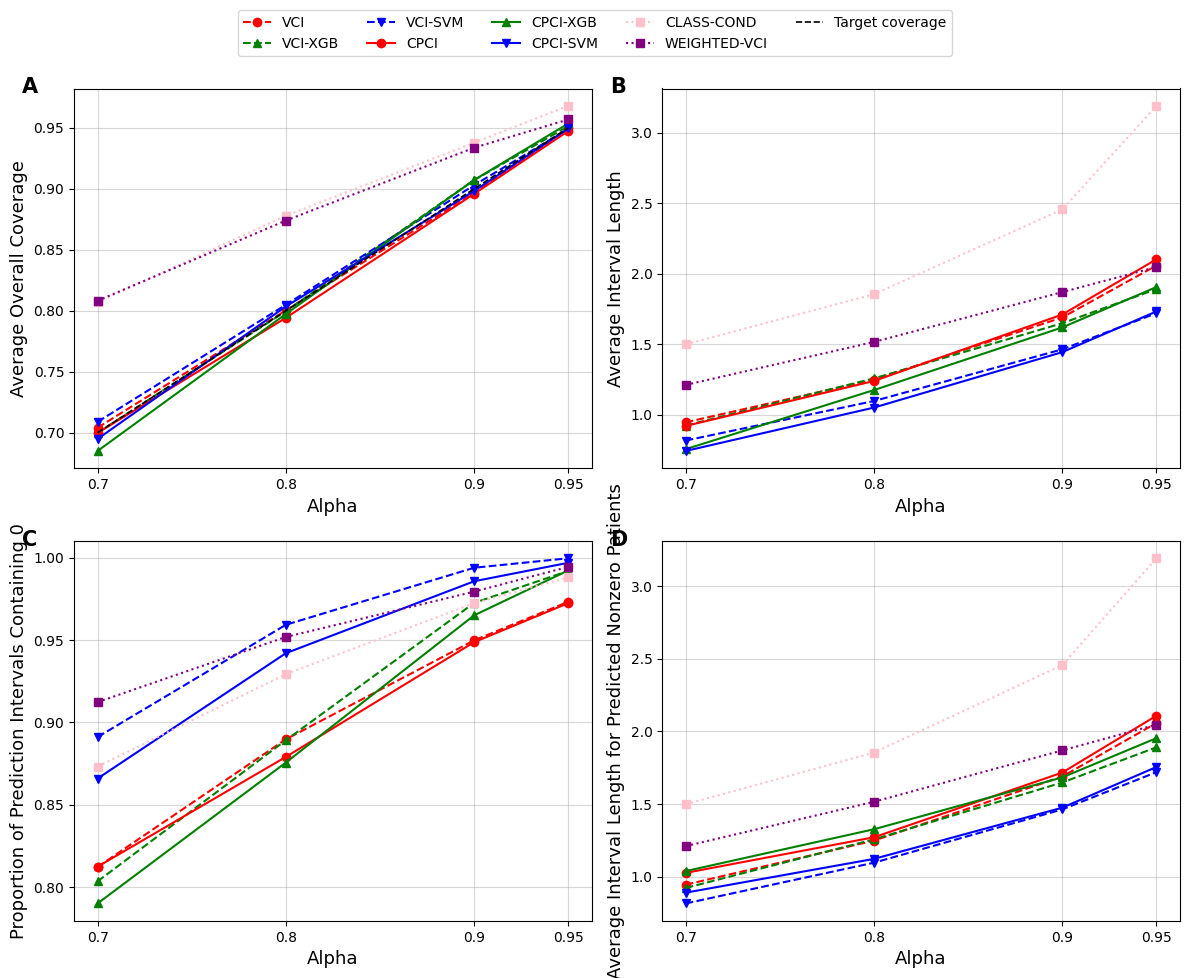

Saved to conformal_comparison_8methods_4panels.png


In [12]:
# ==============================================================================
# OLD CODE COMMENTED OUT
# ==============================================================================
# # Color / style scheme — one entry per method
# style = {
#     'CPCI':         {'color': 'green',   'marker': 'o', 'ls': '-'},
#     'VCI':          {'color': 'red',     'marker': 'o', 'ls': '--'},
#     'CPCI-XGB':     {'color': 'purple',  'marker': 's', 'ls': '-'},
#     'WEIGHTED-VCI': {'color': 'orange',  'marker': 'D', 'ls': '-'},
#     'CLASS-COND':   {'color': 'steelblue','marker': '^', 'ls': '-'},
# }
#
# fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# x_ticks = ALPHA_VALUES
#
# # ── Coverage ─────────────────────────────────────────────────────────────────
# for name, r in results.items():
#     s = style[name]
#     ax[0].plot(r['alpha'], r['coverage'],
#                color=s['color'], marker=s['marker'], linestyle=s['ls'],
#                label=f"{name}")
#     ax[0].plot(r['alpha'], r['coverage_nonzero'],
#                color=s['color'], marker=s['marker'], linestyle=':',
#                alpha=0.55)
#
# # Identity line (desired coverage)
# ax[0].plot(x_ticks, x_ticks, linestyle='--', color='gray',
#            linewidth=1, label='Desired (α)')
# ax[0].set_xticks(x_ticks); ax[0].set_xticklabels(x_ticks)
# ax[0].set_xlabel('α', fontsize=13)
# ax[0].set_ylabel('Coverage', fontsize=13)
# ax[0].set_title('Coverage (solid=overall, dotted=non-zero)', fontsize=12)
# ax[0].grid(True, alpha=0.4)
# ax[0].text(-0.02, 1.02, 'A', transform=ax[0].transAxes,
#            fontsize=15, fontweight='bold', va='top')
#
# # ── Interval Width ────────────────────────────────────────────────────────────
# for name, r in results.items():
#     s = style[name]
#     ax[1].plot(r['alpha'], r['avg_width'],
#                color=s['color'], marker=s['marker'], linestyle=s['ls'],
#                label=f"{name}")
#     ax[1].plot(r['alpha'], r['avg_width_nonzero'],
#                color=s['color'], marker=s['marker'], linestyle=':',
#                alpha=0.55)
#
# ax[1].set_xticks(x_ticks); ax[1].set_xticklabels(x_ticks)
# ax[1].set_xlabel('α', fontsize=13)
# ax[1].set_ylabel('Average Interval Width', fontsize=13)
# ax[1].set_title('Interval Width (solid=overall, dotted=non-zero)', fontsize=12)
# ax[1].grid(True, alpha=0.4)
# ax[1].text(-0.12, 1.02, 'B', transform=ax[1].transAxes,
#            fontsize=15, fontweight='bold', va='top')
#
# handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=6,
#            fontsize=10, bbox_to_anchor=(0.5, 1.0), frameon=True)
# plt.tight_layout(rect=[0, 0, 1, 0.93])
# plt.savefig('conformal_comparison.png', transparent=True, bbox_inches='tight', dpi=150)
# plt.show()
# print("Saved to conformal_comparison.png")

# ==============================================================================
# UPDATED CODE
# ==============================================================================

# dashed = VCI variants, solid = CPCI variants, dotted = baseline methods.
style = {
    'VCI':          {'color': 'red',       'marker': 'o', 'ls': '--'},
    'VCI-XGB':      {'color': 'green',     'marker': '^', 'ls': '--'},
    'VCI-SVM':      {'color': 'blue',      'marker': 'v', 'ls': '--'},

    'CPCI':         {'color': 'red',       'marker': 'o', 'ls': '-'},
    'CPCI-XGB':     {'color': 'green',     'marker': '^', 'ls': '-'},
    'CPCI-SVM':     {'color': 'blue',      'marker': 'v', 'ls': '-'},

    'CLASS-COND':   {'color': 'pink',      'marker': 's', 'ls': ':'},
    'WEIGHTED-VCI': {'color': 'purple',    'marker': 's', 'ls': ':'},
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
x_ticks = ALPHA_VALUES

plot_config = [
    (axes[0, 0], 'coverage', 'Average Overall Coverage', 'A'),
    (axes[0, 1], 'avg_width', 'Average Interval Length', 'B'),
    (axes[1, 0], 'inclusion_zero', 'Proportion of Prediction Intervals Containing 0', 'C'),
    (axes[1, 1], 'avg_width_pred_nonzero', 'Average Interval Length for Predicted Nonzero Patients', 'D'),
]

for ax, metric, ylabel, panel_label in plot_config:
    for name, r in results.items():
        s = style[name]
        ax.plot(
            r['alpha'], r[metric],
            color=s['color'],
            marker=s['marker'],
            linestyle=s['ls'],
            label=name
        )

    if metric == 'coverage':
        ax.plot(x_ticks, x_ticks, linestyle='--', color='black',
                linewidth=1.2, label='Target coverage')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks)
    ax.set_xlabel('Alpha', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(True, alpha=0.5)
    ax.text(
        -0.10, 1.03, panel_label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top'
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
# Remove duplicate "Target coverage" if needed
seen = set()
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        unique_handles.append(h)
        unique_labels.append(l)
        seen.add(l)

fig.legend(
    unique_handles,
    unique_labels,
    loc='upper center',
    ncol=5,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.98),
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('conformal_comparison_8methods_4panels.png',
            transparent=True, bbox_inches='tight', dpi=150)
plt.show()

print("Saved to conformal_comparison_8methods_4panels.png")
